In [1]:
import pandas as pd

df = pd.read_csv('/maiziezhou_lab2/yunfei/Projects/interpTFM/scripts/runs/full_scgpt_cosmx/heldout_report/layer_4.norm2/valid_concept_f1_scores.csv')

In [5]:
df

,concept,feature,threshold_pct,precision,recall,f1,tp,fp,fn
0,GO:0007166,2527,0.0,0.583219,0.134909,0.219130,17808,12726,114192
1,GO:0007166,1858,0.0,0.767253,0.125492,0.215704,16565,5025,115435
2,GO:0007166,1144,0.0,0.485632,0.137121,0.213858,18100,19171,113900
3,GO:0007166,1145,0.0,0.652633,0.126477,0.211891,16695,8886,115305
4,GO:0007166,3573,0.0,0.559389,0.129083,0.209762,17039,13421,114961
...,...,...,...,...,...,...,...,...,...
4587195,GO:0016125,2312,0.6,0.057525,0.612784,0.105177,3988,65338,2520
4587196,GO:0016125,3533,0.6,0.056419,0.769668,0.105132,5009,83773,1499
4587197,GO:0016125,1922,0.6,0.055398,0.960664,0.104755,6252,106604,256
4587198,GO:0016125,1496,0.6,0.088621,0.127689,0.104627,831,8546,5677


In [4]:
df['f1'].sort_values()

2874332    0.0
3990926    0.0
3990927    0.0
3990928    0.0
3990929    0.0
          ... 
3003800    1.0
1402400    1.0
2112600    1.0
1570800    1.0
2981800    1.0
Name: f1, Length: 4587200, dtype: float64

Original rows: 4587200
Unique features: 3888
Rows after best-per-feature filter: 3888


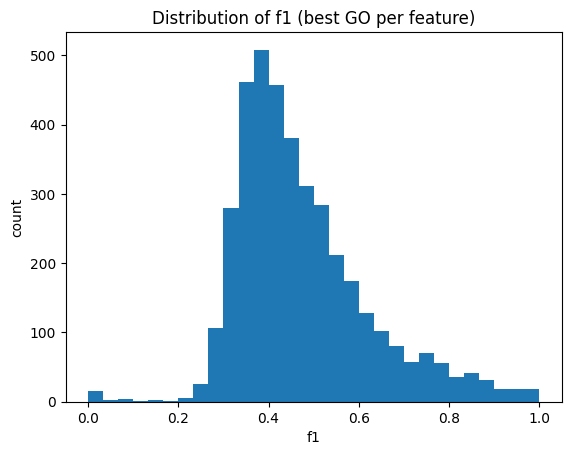

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Keep only the top GO (concept) per feature by highest f1
#    (ties broken by higher precision, then higher recall, then first occurrence)
df_best = (
    df.sort_values(["feature", "f1", "precision", "recall"], ascending=[True, False, False, False])
      .drop_duplicates(subset=["feature"], keep="first")
      .reset_index(drop=True)
)

print("Original rows:", len(df))
print("Unique features:", df["feature"].nunique())
print("Rows after best-per-feature filter:", len(df_best))

# 2) Plot histogram of f1 after filtering
x = df_best["f1"].dropna()

plt.figure()
plt.hist(x, bins=30)
plt.title("Distribution of f1 (best GO per feature)")
plt.xlabel("f1")
plt.ylabel("count")
plt.show()

In [ ]:
x>0.5

0       False
1       False
2        True
3       False
4       False
        ...  
3883     True
3884     True
3885    False
3886     True
3887    False
Name: f1, Length: 3888, dtype: bool